# **Week 7: 卷积神经网络（CNN）- 胸部X光片肺炎智能诊断**

---

## **本节课学习目标**
- 理解卷积神经网络（CNN）的基本概念和工作原理
- 学习CNN如何自动从医学影像中提取特征
- 掌握使用PyTorch构建简单的CNN模型
- 完成一个胸部X光片肺炎诊断任务

---

# **第一部分：医学背景引入**

## **临床场景**

想象你是一名放射科医生，每天需要分析大量的胸部X光片。你的任务是快速判断患者的胸片中是否存在肺炎。

**传统方法 vs AI方法：**

- **传统方法**：医生需要多年训练才能准确识别胸片中的肺炎特征（如肺部浸润、斑片状阴影等）。面对大量患者时，工作量大，容易疲劳导致漏诊。
- **AI方法**：卷积神经网络可以"看"胸片图像，自动学习识别肺炎的影像学特征，辅助医生快速筛查，减少漏诊率。

**本次任务：**

我们将使用 **PneumoniaMNIST** 数据集，这是一个来自真实临床的儿科胸部X光片数据集。每张图像是一个 64×64 像素的灰度图像，我们需要将图像分类为 2 类：**正常（Normal）** vs **肺炎（Pneumonia）**。

**数据集来源：**
- 原始数据集包含 5,856 张儿童胸部X光片
- 源数据集：Daniel S. Kermany, Michael Goldbaum, et al., "Identifying medical diagnoses and treatable diseases by image-based deep learning," Cell, vol. 172, no. 5, pp. 1122 – 1131.e9, 2018.
- 影像中心裁剪后调整为 64×64 像素，便于教学使用

---

# **第二部分：CNN 原理讲解（直觉理解）**

## **CNN 为什么适合影像任务？**

**类比理解：**

想象你第一次看一张胸部X光片，你会怎么做？

1. **先看整体结构**：了解胸廓、心脏、横膈的大致形态
2. **再关注局部细节**：仔细查看肺野区域，寻找异常阴影或浸润
3. **综合判断**：结合整体和局部特征做出诊断

CNN 的工作方式正是模仿这个过程！

---

## **CNN 的核心组件**

### **1. 卷积层（Conv2d）——"眼睛"**

想象你在用一个小的"窗口"（比如 3×3）在胸片上滑动。这个窗口就像一个"探测器"，专门寻找某些模式（如肺部纹理、血管走向、异常阴影边缘）。

- **作用**：提取图像中的局部特征
- **类比**：医生用放大镜仔细观察肺野某个区域的影像细节

### **2. 池化层（MaxPool2d）——"缩小镜"**

提取特征后，我们不需要保留所有像素细节，只需要最重要的信息。

- **作用**：降低数据维度，保留主要特征
- **类比**：医生从整体上评估肺炎病灶的范围和分布

### **3. 全连接层（Linear）——"大脑"**

把提取到的所有影像特征综合起来，做出最终判断。

- **作用**：分类决策
- **类比**：医生综合胸片各项影像表现和患者症状做出诊断

---

## **CNN vs 全连接神经网络**

| 特性 | 全连接神经网络 | CNN |
|------|---------------|-----|
| 输入方式 | 把图像展平成一维向量 | 直接使用2D/3D图像 |
| 参数量 | 很多，容易过拟合 | 相对较少 |
| 适用任务 | 表格数据 | 图像、影像数据 |

---

# **第三部分：数据准备**

## **MedMNIST 数据集简介**

**MedMNIST** 是一个大规模的医学影像基准数据集，旨在为医学图像分类提供一个标准化的测试平台。

### **MedMNIST 包含的子数据集**

MedMNIST 数据集包含 12 个预处理的 2D 数据集和 6 个预处理的 3D 数据集，这些数据集来自选定的来源，涵盖了主要的数据模态（例如 X 射线、光学相干断层扫描、超声、计算机断层扫描、电子显微镜），多样化的分类任务（二元/多元分类、序数回归和多标签）以及不同的数据规模（从 100 到 100,000）。

MedMNIST 包含 **12 个2D图像子数据集**：

| MedMNIST2D 数据集 | 数据模态         | 任务（类别数/标签数） | 样本总数 |
|-------------------|------------------|------------------------|----------|
| PathMNIST         | 结肠病理         | 多分类 (9)             | 107,180  |
| ChestMNIST        | 胸部X光片        | 多标签 (14) 二分类 (2) | 112,120  |
| DermaMNIST        | 皮肤镜图像       | 多分类 (7)             | 10,015   |
| OCTMNIST          | 视网膜OCT        | 多分类 (4)             | 109,309  |
| PneumoniaMNIST ⭐   | 胸部X光片        | 二分类 (2)             | 5,856    |
| RetinaMNIST       | 眼底相机图像     | 有序回归 (5)           | 1,600    |
| BreastMNIST       | 乳腺超声图像     | 二分类 (2)             | 780      |
| BloodMNIST        | 血细胞显微镜图像 | 多分类 (8)             | 17,092   |
| TissueMNIST       | 肾皮质显微镜图像 | 多分类 (8)             | 236,386  |
| OrganAMNIST       | 腹部CT           | 多分类 (11)            | 58,830   |
| OrganCMNIST       | 腹部CT           | 多分类 (11)            | 23,583   |
| OrganSMNIST       | 腹部CT           | 多分类 (11)            | 25,211   |

⭐ **本次课程使用的数据集**

### **MedMNIST 数据集特点**

- **多样**：它涵盖了多种数据模式、数据集规模（从 100 到 100,000）以及任务（二分类/多分类、多标签和序数回归），能够公平地评估不同设置下机器学习算法的泛化性能，但同时提供了 2D 和 3D 生物医学图像。

- **标准化**：每个子数据集都预处理为相同的格式，用户无需具备背景知识。作为类似 MNIST 的数据集集合，用于在小图像上执行分类任务此外，我们为 MedMNIST 中的所有数据集提供了标准的训练集 - 验证集 - 测试集划分，因此算法可以轻松进行比较。

- **用户友好**：28×28（2D）或 28×28×28（3D）的小尺寸轻量且适合评估机器学习算法。我们还提供了更大尺寸的版本 MedMNIST+：64x64（2D）、128x128（2D）、224x224（2D）和 64x64x64（3D）作为 28 尺寸 MedMNIST 的补充，这可以成为开发医学基础模型的标准化资源。

请注意，此数据集不适用于临床用途。

---

## **使用其他 MedMNIST 数据集**

如果你想尝试其他数据集，只需修改一行代码：

```python
# 只需要修改 data_flag 变量即可切换数据集
data_flag = 'chestmnist'      # 胸片多分类
# data_flag = 'pathmnist'     # 病理切片
# data_flag = 'dermamnist'    # 皮肤镜
```

### **官方资源**

- **GitHub 仓库**: [https://github.com/MedMNIST/MedMNIST](https://github.com/MedMNIST/MedMNIST)
- **官方网站**: [https://medmnist.com/](https://medmnist.com/)
- **论文**: "MedMNIST v2 -- A large-scale lightweight benchmark for 2D and 3D biomedical image classification"

---

## **安装必要的库**

首先我们需要安装 medmnist 库。

In [1]:
# 安装 medmnist 库

!pip install medmnist

## **导入必要的库**

In [2]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

# Windows 系统设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 导入 medmnist 库
import medmnist
from medmnist import INFO

print(f"MedMNIST 版本: {medmnist.__version__}")

MedMNIST 版本: 3.0.2


## **设置随机种子（保证可复现性）**

为了确保每次运行代码时结果一致，我们需要设置随机种子。这包括：
- PyTorch 随机种子
- NumPy 随机种子
- CUDA 随机种子（如果使用 GPU）
- Python 随机模块种子

#### **为什么需要设置随机种子？**

1. **权重初始化**：神经网络的权重是随机初始化的
2. **数据 shuffle**：训练时数据加载器会随机打乱数据顺序
3. **Dropout**：Dropout 层会随机丢弃神经元

如果不设置种子，每次运行结果都会不同。

In [3]:
# 设置随机种子（保证可复现性）
import random

# 设置随机种子
RANDOM_SEED = 22  # 可以改为任意整数，建议使用固定值

# 设置 Python 随机模块种子
random.seed(RANDOM_SEED)

# 设置 NumPy 随机种子
np.random.seed(RANDOM_SEED)

# 设置 PyTorch 随机种子
torch.manual_seed(RANDOM_SEED)

# 如果使用 CUDA（GPU），也设置 CUDA 随机种子
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# 设置确定性模式（可选，但会降低训练速度）
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

print(f"随机种子已设置为: {RANDOM_SEED}")

随机种子已设置为: 22


## **配置数据集参数**

我们将使用 PneumoniaMNIST 数据集。注意：虽然 MedMNIST 标准图像尺寸是 28×28，但数据加载库支持自定义尺寸，这里我们使用 64×64 以获得更好的分类效果。

In [4]:
# 数据集配置
data_flag = 'pneumoniamnist'  # 数据集名称
IMAGE_SIZE = 64           # 图像尺寸
BATCH_SIZE = 64          # 批次大小
NUM_EPOCHS = 8          # 训练轮数
LEARNING_RATE = 0.001    # 学习率

# 获取数据集信息（INFO[data_flag]）
info = INFO[data_flag]

# 打印数据集信息
print("=" * 50)
print("数据集信息:")
print(f"任务类型: {info['task']}")
print(f"通道数: {info['n_channels']}")
print(f"类别数: {len(info['label'])}")
print(f"类别标签: {info['label']}")
print(f"数据集描述: {info['description']}")
print(f"训练集样本数: {info['n_samples']['train']}")
print(f"验证集样本数: {info['n_samples']['val']}")
print(f"测试集样本数: {info['n_samples']['test']}")
print("=" * 50)

数据集信息:
任务类型: binary-class
通道数: 1
类别数: 2
类别标签: {'0': 'normal', '1': 'pneumonia'}
数据集描述: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
训练集样本数: 4708
验证集样本数: 524
测试集样本数: 624


## **加载数据集**

MedMNIST 数据集已经预划分为训练集、验证集和测试集，我们可以直接加载使用。

In [5]:
# 获取数据集类
DataClass = getattr(medmnist, info['python_class'])

# 定义数据预处理（transforms.Compose）
# ToTensor 将 PIL 图像或 numpy 数组转换为 PyTorch 张量，同时，将图像的像素值从[0, 255]的范围自动归一化到[0.0, 1.0]的浮点数范围
# Normalize 将像素值归一化到 [-1, 1] 范围，公式：normalized = (tensor - mean) / std
# 实现将图片的像素值从[0, 255]的整数范围，最终转换成范围在[-1.0, 1.0]之间的、均值为0、标准差为1的张量

data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  
])

# 加载训练集、验证集和测试集
# MedMNIST 数据集已经预划分好了：
# - split='train': 训练集
# - split='val': 验证集
# - split='test': 测试集

train_dataset = DataClass(split='train', transform=data_transform, download=True, size=IMAGE_SIZE)
val_dataset = DataClass(split='val', transform=data_transform, download=True, size=IMAGE_SIZE)
test_dataset = DataClass(split='test', transform=data_transform, download=True, size=IMAGE_SIZE)

print(f"训练集样本数: {len(train_dataset)}")
print(f"验证集样本数: {len(val_dataset)}")
print(f"测试集样本数: {len(test_dataset)}")

训练集样本数: 4708
验证集样本数: 524
测试集样本数: 624


## **创建数据加载器**

DataLoader 负责将数据集分批次提供给模型。我们需要为训练集、验证集和测试集分别创建 DataLoader。

In [6]:
# TODO: 创建训练集、验证集和测试集的 DataLoader
# 提示：使用 DataLoader
# - 训练集需要 shuffle=True (打乱顺序)
# - 验证集和测试集不需要 shuffle=False (保持顺序)
# 这样可以在训练过程中使用验证集监控模型是否过拟合

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"训练集批次数: {len(train_loader)}")
print(f"验证集批次数: {len(val_loader)}")
print(f"测试集批次数: {len(test_loader)}")

训练集批次数: 74
验证集批次数: 9
测试集批次数: 10


## **数据集标签分布**

在训练模型之前，让我们先看看训练集、验证集和测试集中各个类别的分布情况。这有助于我们了解数据是否平衡，以及模型可能面临的挑战。

**为什么数据平衡很重要？**
- 如果某个类别的样本远多于其他类别，模型可能会偏向于预测多数类
- 对于医学诊断任务，数据不平衡可能导致对少数类（如罕见疾病）的识别能力下降


训练集 标签分布:
normal (类别 0): 1214 样本 (25.8%)
pneumonia (类别 1): 3494 样本 (74.2%)

验证集 标签分布:
normal (类别 0): 135 样本 (25.8%)
pneumonia (类别 1): 389 样本 (74.2%)

测试集 标签分布:
normal (类别 0): 234 样本 (37.5%)
pneumonia (类别 1): 390 样本 (62.5%)


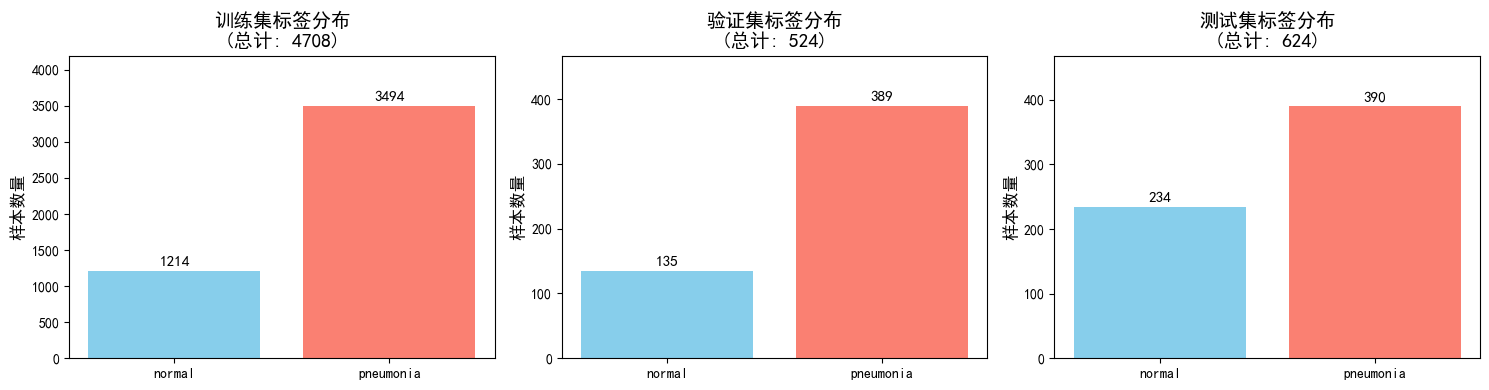

In [7]:
# 统计各个数据集的标签分布

from collections import Counter

def get_label_distribution(dataset, name):
    """
    获取数据集的标签分布
    
    参数:
        dataset: 数据集
        name: 数据集名称
    
    返回:
        label_counts: 各类别的样本数量
    """
    label_counts = Counter()
    
    # 遍历数据集，统计标签
    for _, label in dataset:
        label_counts[label.item()] += 1
    
    # 打印分布
    print(f"\n{name} 标签分布:")
    print("=" * 50)
    total = len(dataset)
    for label_idx in sorted(label_counts.keys()):
        count = label_counts[label_idx]
        percentage = count / total * 100
        label_name = info['label'][str(label_idx)]
        print(f"{label_name} (类别 {label_idx}): {count} 样本 ({percentage:.1f}%)")
    print("=" * 50)
    
    return label_counts

# 获取各数据集的标签分布
train_label_counts = get_label_distribution(train_dataset, "训练集")
val_label_counts = get_label_distribution(val_dataset, "验证集")
test_label_counts = get_label_distribution(test_dataset, "测试集")

# 可视化标签分布
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [(train_label_counts, "训练集", len(train_dataset)), 
            (val_label_counts, "验证集", len(val_dataset)), 
            (test_label_counts, "测试集", len(test_dataset))]

for idx, (counts, name, total) in enumerate(datasets):
    labels = [info['label'][str(i)] for i in sorted(counts.keys())]
    values = [counts[i] for i in sorted(counts.keys())]
    
    axes[idx].bar(labels, values, color=['skyblue', 'salmon'])
    axes[idx].set_ylabel('样本数量', fontsize=12)
    axes[idx].set_title(f'{name}标签分布\n(总计: {total})', fontsize=14, fontweight='bold')
    axes[idx].set_ylim(0, max(values) * 1.2)
    
    # 在柱子上显示数值
    for i, v in enumerate(values):
        axes[idx].text(i, v + max(values)*0.02, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## **处理类别不平衡：加权损失函数**

**问题：** 从数据分布图中可以看到，肺炎样本（类别1）远多于正常样本（类别0），存在类别不平衡。

**影响：** 模型会倾向于预测多数类（肺炎），因为这样可以获得更高的整体准确率，但对少数类（正常）的识别能力下降。

**解决方法：加权损失函数**

PyTorch 的 `CrossEntropyLoss` 支持 `weight` 参数，我们可以：
- 给 **少数类-正常**更高的权重，让模型更关注少数类
- 给 **多数类-肺炎**更低的权重
- 权重通常设置为类别数量的反比：`weight = total_samples / (num_classes * class_samples)`

```python
# 示例权重计算
# 假设训练集有 1000 个正常样本，4000 个肺炎样本
# 总共 5000 个样本，2 个类别
# 正常类权重 = 5000 / (2 * 1000) = 2.5
# 肺炎类权重 = 5000 / (2 * 4000) = 0.625
```

## **可视化数据集**

让我们看看数据集中的胸部X光片长什么样。

图像批次形状: torch.Size([64, 1, 64, 64])
标签批次形状: torch.Size([64, 1])


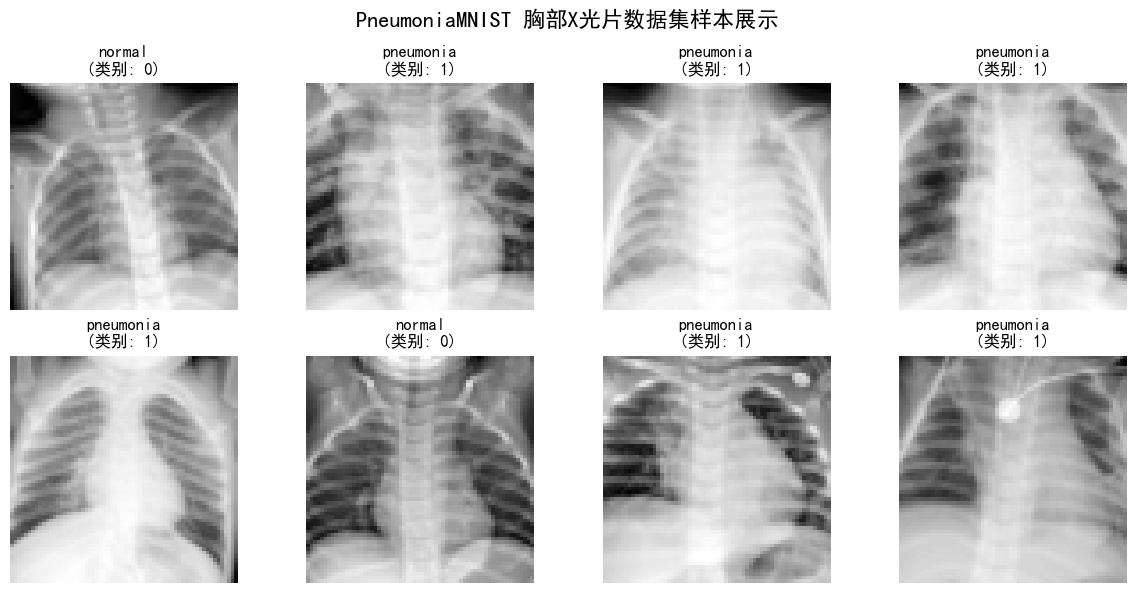

In [8]:
# 获取一个批次的图像
images, labels = next(iter(train_loader))

print(f"图像批次形状: {images.shape}")  # [batch_size, channels, height, width]
print(f"标签批次形状: {labels.shape}")

# 可视化前8张图像
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('PneumoniaMNIST 胸部X光片数据集样本展示', fontsize=16)

for i in range(8):
    ax = axes[i // 4, i % 4]
    # 将图像从 [-1, 1] 转换回 [0, 1] 用于显示
    img = images[i].squeeze().numpy() * 0.5 + 0.5  # 灰度图像，需要squeeze去掉通道维度
    img = np.clip(img, 0, 1)
    
    ax.imshow(img, cmap='gray')  # 使用灰度色图
    # 获取类别名称
    label_idx = labels[i].item()
    label_name = info['label'][str(label_idx)]
    ax.set_title(f'{label_name}\n(类别: {label_idx})')
    ax.axis('off')

plt.tight_layout()
plt.show()

---

# **第四部分：模型构建**

现在我们来构建一个简单的 CNN 模型。这个模型将包含多个卷积层和池化层，最后接全连接层进行分类。

**CNN 模型结构：**

```
输入胸片图像 (1 × 64 × 64)
    ↓
卷积层 1 + 批归一化 + ReLU (提取初级特征)
    ↓
卷积层 2 + 批归一化 + ReLU + 最大池化 (下采样)
    ↓
卷积层 3 + 批归一化 + ReLU (提取更高级特征)
    ↓
卷积层 4 + 批归一化 + ReLU + 最大池化 (进一步下采样)
    ↓
展平 (Flatten)
    ↓
全连接层 1 + ReLU
    ↓
全连接层 2 + ReLU
    ↓
输出层 (2个类别: 正常 vs 肺炎)
```

In [9]:
# 定义 CNN 模型
class SimpleCNN(nn.Module):
    def __init__(self, in_channels, num_classes, image_size=64):
        super(SimpleCNN, self).__init__()
        
        # TODO: 定义卷积层 1 (Conv2d)
        # 提示：使用 nn.Conv2d(in_channels, 16, kernel_size=3, padding=1) # padding=1 保持图像尺寸
        # 提示：然后添加 nn.BatchNorm2d 和 nn.ReLU
        
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),  
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        
        # TODO: 定义卷积层 2 + 池化层
        # 提示：Conv2d + BatchNorm2d + ReLU + MaxPool2d(kernel_size=2, stride=2)
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 图像尺寸减半
        )
        
        # 卷积层 3
        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        # 卷积层 4 + 池化层        
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 图像尺寸再减半
        )
        
        # 计算展平后的特征维度
        # 经过两次 MaxPool2d（每次减半），图像尺寸变为 image_size / 2 / 2
        # 最终特征图大小: 128 × (image_size/4) × (image_size/4)
        feature_map_size = image_size // 4  # 两次池化后图像尺寸
        self.feature_size = 128 * feature_map_size * feature_map_size
        
        # TODO: 定义全连接层
        # 提示：Linear + ReLU + Dropout(0.5) + Linear + ReLU + nn.Dropout(0.3) + Linear(输出层)
        
        self.fc = nn.Sequential(
            nn.Linear(self.feature_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),  # 防止过拟合
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        
        # 完成前向传播，依次通过各个层
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # 展平
        x = x.view(x.size(0), -1)
        
        # 全连接层
        x = self.fc(x)
        
        return x

# 创建模型实例
model = SimpleCNN(in_channels=info['n_channels'], num_classes=len(info['label']), image_size=IMAGE_SIZE)

# 打印模型结构
print("=" * 60)
print("模型结构:")
print("=" * 60)
print(model)
print("=" * 60)
print(f"模型总参数量: {sum(p.numel() for p in model.parameters()):,}")
print(f"展平后特征维度: {model.feature_size:,}")

模型结构:
SimpleCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

---

# **第五部分：模型训练**

## **定义损失函数和优化器**

- **损失函数（Loss Function）**：衡量模型预测结果与真实标签之间的差距
  - 交叉熵损失（CrossEntropyLoss）：二分类和多分类任务的常用损失函数

- **优化器（Optimizer）**：根据损失函数调整模型参数
  - SGD（随机梯度下降）：简单常用的优化算法
  - Adam：自适应学习率，通常收敛更快

In [10]:
# TODO: 定义损失函数
# 提示：多分类任务使用 nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss()

# TODO: 定义优化器
# 提示：使用 optim.SGD，传入模型参数、学习率和动量
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

print(f"损失函数: {criterion}")
print(f"优化器: {optimizer}")

损失函数: CrossEntropyLoss()
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


## **训练循环**

训练过程包含以下步骤：

1. **前向传播**：输入胸片图像通过网络，得到预测结果
2. **计算损失**：比较预测结果和真实标签
3. **反向传播**：根据损失计算梯度
4. **参数更新**：根据梯度更新模型参数

In [11]:
# 导入评估指标所需的库
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

# 定义评估函数（用于验证集和测试集）
def evaluate(model, data_loader, criterion, num_classes):
    """
    在给定数据集上评估模型
    
    参数:
        model: 要评估的模型
        data_loader: 数据加载器
        criterion: 损失函数
        num_classes: 类别数量
    
    返回:
        metrics_dict: 包含各种指标的字典
    """
    model.eval()  # 设置为评估模式
    total_loss = 0.0
    correct = 0
    total = 0

    # 用于计算F1和其他指标的列表
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in data_loader:
            # TODO: 前向传播
            outputs = model(inputs)
            
            # 计算损失
            targets = targets.squeeze().long()
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            
            # 获取预测结果
            _, predicted = outputs.max(1)
            
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            # 保存预测结果和真实标签用于计算F1
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = 100. * correct / total
    
    # 计算F1分数
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)
    
    # 计算宏平均F1
    macro_f1 = f1_score(all_targets, all_predictions, average='macro', zero_division=0)
    # 计算微平均F1
    micro_f1 = f1_score(all_targets, all_predictions, average='micro', zero_division=0)
    # 计算加权F1
    weighted_f1 = f1_score(all_targets, all_predictions, average='weighted', zero_division=0)
    
    # 计算每个类别的F1
    per_class_f1 = f1_score(all_targets, all_predictions, average=None, labels=range(num_classes))
    
    # 计算精确率和召回率
    precision = precision_score(all_targets, all_predictions, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_predictions, average='macro', zero_division=0)
    
    # 计算混淆矩阵
    cm = confusion_matrix(all_targets, all_predictions, labels=range(num_classes))
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'macro_f1': macro_f1 * 100,  # 转为百分比
        'micro_f1': micro_f1 * 100,
        'weighted_f1': weighted_f1 * 100,
        'per_class_f1': per_class_f1 * 100,
        'precision': precision * 100,
        'recall': recall * 100,
        'confusion_matrix': cm
    }

# 训练函数（同时记录训练集和验证集的指标）
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, num_classes, model_name="模型"):
    """
    训练模型并在验证集上评估
    
    参数:
        model: 要训练的模型
        train_loader: 训练数据加载器
        val_loader: 验证数据加载器
        criterion: 损失函数
        optimizer: 优化器
        num_epochs: 训练轮数
        num_classes: 类别数量
        model_name: 模型名称（用于打印）
    
    返回:
        metrics_dict: 包含各种指标的字典
    """
    train_losses = []
    train_accs = []
    train_f1s = []
    val_losses = []
    val_accs = []
    val_f1s = []
    
    # 记录最佳验证集F1分数
    best_val_f1 = 0.0
    best_model_state = None
    
    for epoch in range(num_epochs):
        # ========== 训练阶段 ==========
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        all_train_preds = []
        all_train_targets = []
        
        pbar = tqdm(train_loader, desc=f'[{model_name}] Epoch {epoch+1}/{num_epochs}')
        
        for inputs, targets in pbar:
            optimizer.zero_grad()
            
            outputs = model(inputs)
            targets = targets.squeeze().long()
            loss = criterion(outputs, targets)

            # TODO: 反向传播和参数更新
            # 提示：1. loss.backward() 反向传播
            #      2. optimizer.step() 更新参数
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # 保存训练预测
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_targets.extend(targets.cpu().numpy())
            
            pbar.set_postfix({
                'loss': f'{loss:.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
        
        # 计算训练集指标
        train_epoch_loss = running_loss / len(train_loader)
        train_epoch_acc = 100. * correct / total
        
        # 计算训练集F1
        train_epoch_f1 = f1_score(all_train_targets, all_train_preds, average='macro', zero_division=0) * 100
        
        train_losses.append(train_epoch_loss)
        train_accs.append(train_epoch_acc)
        train_f1s.append(train_epoch_f1)
        
        # ========== 验证阶段 ==========
        val_metrics = evaluate(model, val_loader, criterion, num_classes)
        
        val_losses.append(val_metrics['loss'])
        val_accs.append(val_metrics['accuracy'])
        val_f1s.append(val_metrics['macro_f1'])
        
        # 使用F1分数选择最佳模型
        if val_metrics['macro_f1'] > best_val_f1:
            best_val_f1 = val_metrics['macro_f1']
            best_epoch = epoch + 1
            best_model_state = model.state_dict().copy()
        
        # 打印详细的训练和验证结果
        print(f'[{model_name}] Epoch {epoch+1}/{num_epochs}')
        print(f'  Train - Loss: {train_epoch_loss:.4f}, Acc: {train_epoch_acc:.2f}%, F1: {train_epoch_f1:.2f}%')
        print(f'  Val   - Loss: {val_metrics["loss"]:.4f}, Acc: {val_metrics["accuracy"]:.2f}%, '
              f'F1: {val_metrics["macro_f1"]:.2f}%, Prec: {val_metrics["precision"]:.2f}%, '
              f'Recall: {val_metrics["recall"]:.2f}%')
    
    print("=" * 60)
    print(f"[{model_name}] 训练完成！最佳验证集F1分数: {best_val_f1:.2f}% (Epoch {best_epoch})")
    print("=" * 60)
    
    # 保存最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'train_f1s': train_f1s,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'val_f1s': val_f1s,
        'best_val_f1': best_val_f1,
        'best_epoch': best_epoch
    }

In [12]:
# 开始训练
print("开始训练...")
print("=" * 60)

# 调用训练函数，传入 num_classes 参数
train_results = train_model(
    model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, 
    num_classes=len(info['label']), 
    model_name="普通 CrossEntropyLoss"
)

# 从返回的字典中提取训练和验证指标
train_losses = train_results['train_losses']
train_accs = train_results['train_accs']
train_f1s = train_results['train_f1s']
val_losses = train_results['val_losses']
val_accs = train_results['val_accs']
val_f1s = train_results['val_f1s']
best_val_f1 = train_results['best_val_f1']
best_epoch = train_results['best_epoch']

开始训练...


[普通 CrossEntropyLoss] Epoch 1/8: 100%|██████████████████████| 74/74 [00:42<00:00,  1.74it/s, loss=0.2366, acc=88.04%]


[普通 CrossEntropyLoss] Epoch 1/8
  Train - Loss: 0.2782, Acc: 88.04%, F1: 83.63%
  Val   - Loss: 0.1146, Acc: 95.80%, F1: 94.49%, Prec: 94.71%, Recall: 94.27%


[普通 CrossEntropyLoss] Epoch 2/8: 100%|██████████████████████| 74/74 [00:41<00:00,  1.77it/s, loss=0.1366, acc=95.18%]


[普通 CrossEntropyLoss] Epoch 2/8
  Train - Loss: 0.1262, Acc: 95.18%, F1: 93.69%
  Val   - Loss: 0.1196, Acc: 95.04%, F1: 93.66%, Prec: 92.74%, Recall: 94.72%


...

[普通 CrossEntropyLoss] Epoch 6/8
  Train - Loss: 0.0725, Acc: 97.45%, F1: 96.66%
  Val   - Loss: 0.0755, Acc: 96.37%, F1: 95.25%, Prec: 95.36%, Recall: 95.14%


[普通 CrossEntropyLoss] Epoch 7/8: 100%|██████████████████████| 74/74 [00:42<00:00,  1.74it/s, loss=0.1230, acc=97.32%]


[普通 CrossEntropyLoss] Epoch 7/8
  Train - Loss: 0.0702, Acc: 97.32%, F1: 96.51%
  Val   - Loss: 0.0736, Acc: 96.56%, F1: 95.49%, Prec: 95.71%, Recall: 95.27%


[普通 CrossEntropyLoss] Epoch 8/8: 100%|██████████████████████| 74/74 [00:40<00:00,  1.84it/s, loss=0.0726, acc=97.85%]


[普通 CrossEntropyLoss] Epoch 8/8
  Train - Loss: 0.0610, Acc: 97.85%, F1: 97.19%
  Val   - Loss: 0.0745, Acc: 96.18%, F1: 95.01%, Prec: 95.01%, Recall: 95.01%
[普通 CrossEntropyLoss] 训练完成！最佳验证集F1分数: 95.73% (Epoch 5)


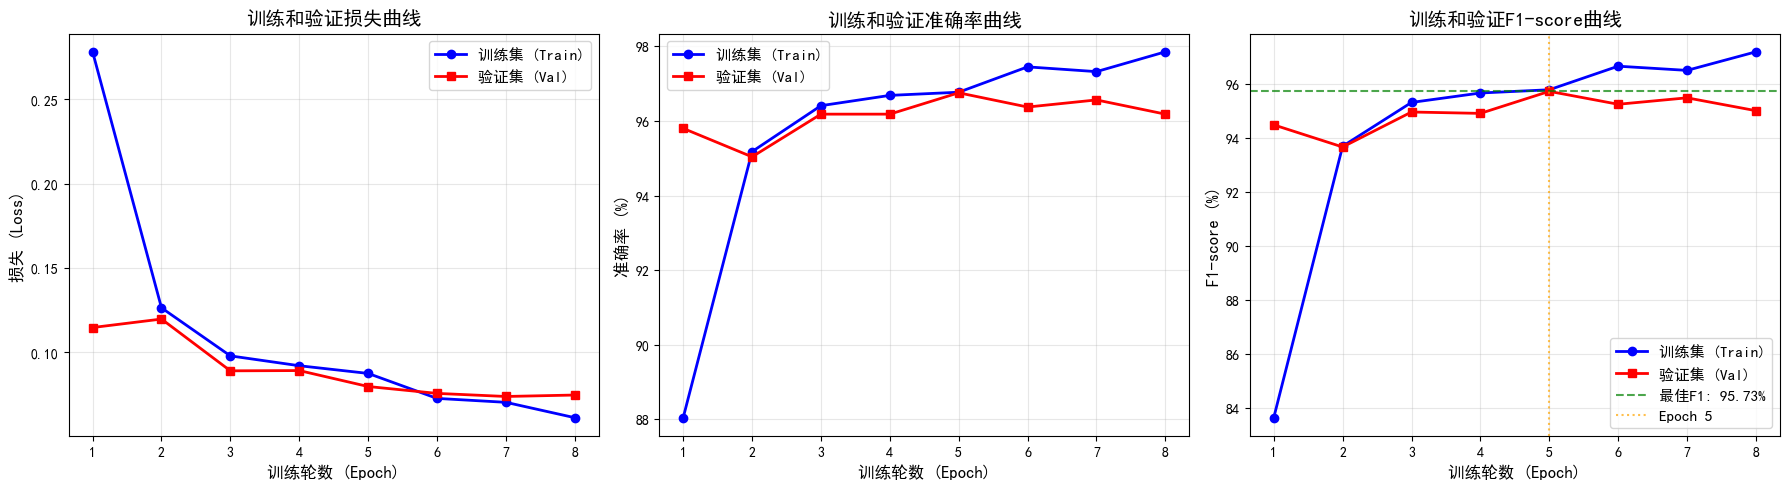

最终训练和验证指标对比:
训练集 - 损失: 0.0610, 准确率: 97.85%, F1: 97.19%
验证集 - 损失: 0.0745, 准确率: 96.18%, F1: 95.01%
差距 - 损失: 0.0134, 准确率: 1.67%, F1: 2.18%
最佳验证集F1分数: 95.73% (Epoch 5)


In [13]:
# 绘制训练过程（同时显示训练集和验证集）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 损失曲线
axes[0].plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', label='训练集 (Train)', linewidth=2, markersize=6)
axes[0].plot(range(1, NUM_EPOCHS+1), val_losses, 'r-s', label='验证集 (Val)', linewidth=2, markersize=6)
axes[0].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[0].set_ylabel('损失 (Loss)', fontsize=12)
axes[0].set_title('训练和验证损失曲线', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(range(1, NUM_EPOCHS+1), train_accs, 'b-o', label='训练集 (Train)', linewidth=2, markersize=6)
axes[1].plot(range(1, NUM_EPOCHS+1), val_accs, 'r-s', label='验证集 (Val)', linewidth=2, markersize=6)
axes[1].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[1].set_ylabel('准确率 (%)', fontsize=12)
axes[1].set_title('训练和验证准确率曲线', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# F1-score 曲线
axes[2].plot(range(1, NUM_EPOCHS+1), train_f1s, 'b-o', label='训练集 (Train)', linewidth=2, markersize=6)
axes[2].plot(range(1, NUM_EPOCHS+1), val_f1s, 'r-s', label='验证集 (Val)', linewidth=2, markersize=6)
axes[2].axhline(y=best_val_f1, color='g', linestyle='--', alpha=0.7, label=f'最佳F1: {best_val_f1:.2f}%')
axes[2].axvline(x=best_epoch, color='orange', linestyle=':', alpha=0.7, label=f'Epoch {best_epoch}')
axes[2].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[2].set_ylabel('F1-score (%)', fontsize=12)
axes[2].set_title('训练和验证F1-score曲线', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印最终指标对比
print("=" * 60)
print("最终训练和验证指标对比:")
print("=" * 60)
print(f"训练集 - 损失: {train_losses[-1]:.4f}, 准确率: {train_accs[-1]:.2f}%, F1: {train_f1s[-1]:.2f}%")
print(f"验证集 - 损失: {val_losses[-1]:.4f}, 准确率: {val_accs[-1]:.2f}%, F1: {val_f1s[-1]:.2f}%")
print(f"差距 - 损失: {abs(train_losses[-1] - val_losses[-1]):.4f}, "
      f"准确率: {abs(train_accs[-1] - val_accs[-1]):.2f}%, "
      f"F1: {abs(train_f1s[-1] - val_f1s[-1]):.2f}%")
print(f"最佳验证集F1分数: {best_val_f1:.2f}% (Epoch {best_epoch})")
print("=" * 60)

#### **在测试集上最终评估模型效果**

在测试集上评估模型...
测试集损失: 0.6087
测试集准确率: 83.81%
测试集 F1-score (宏平均): 80.81%
测试集精确率: 88.27%
测试集召回率: 78.85%

各类别 F1-score:
  normal: 73.21%
  pneumonia: 88.40%

各指标的解释:
- 精确率 (Precision): 预测为肺炎的样本中，真正是肺炎的比例
  - 衡量模型的'谨慎程度'
- 召回率 (Recall): 真正是肺炎的样本中，被正确识别的比例
  - 衡量模型的'全面程度'
- F1-score: 精确率和召回率的调和平均数
  - 综合评估模型的性能
  - 对于类别不平衡的数据集，F1-score 比准确率更可靠


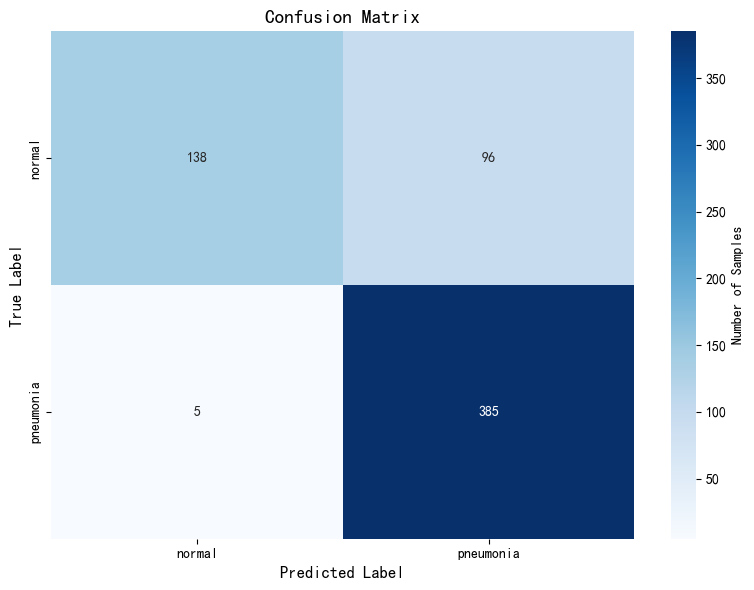

In [14]:
# 在测试集上评估模型
print("在测试集上评估模型...")
print("=" * 60)

# 使用 evaluate 函数在测试集上评估
# 返回一个包含多种指标的字典
test_metrics = evaluate(model, test_loader, criterion, num_classes=len(info['label']))

print(f"测试集损失: {test_metrics['loss']:.4f}")
print(f"测试集准确率: {test_metrics['accuracy']:.2f}%")
print(f"测试集 F1-score (宏平均): {test_metrics['macro_f1']:.2f}%")
print(f"测试集精确率: {test_metrics['precision']:.2f}%")
print(f"测试集召回率: {test_metrics['recall']:.2f}%")
print("=" * 60)

# 打印各类别的 F1-score
print("\n各类别 F1-score:")
for idx, f1 in enumerate(test_metrics['per_class_f1']):
    print(f"  {info['label'][str(idx)]}: {f1:.2f}%")
print("=" * 60)

print("\n" + "=" * 60)
print("各指标的解释:")
print("=" * 60)
print("- 精确率 (Precision): 预测为肺炎的样本中，真正是肺炎的比例")
print("  - 衡量模型的'谨慎程度'")
print("- 召回率 (Recall): 真正是肺炎的样本中，被正确识别的比例")  
print("  - 衡量模型的'全面程度'")
print("- F1-score: 精确率和召回率的调和平均数")
print("  - 综合评估模型的性能")
print("  - 对于类别不平衡的数据集，F1-score 比准确率更可靠")
print("=" * 60)

# 绘制混淆矩阵
cm = test_metrics['confusion_matrix']

# 获取类别名称
class_names = [info['label'][str(i)] for i in range(len(info['label']))]

# 绘制混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## **预测示例**

让我们看看模型对一些测试胸片的预测结果。

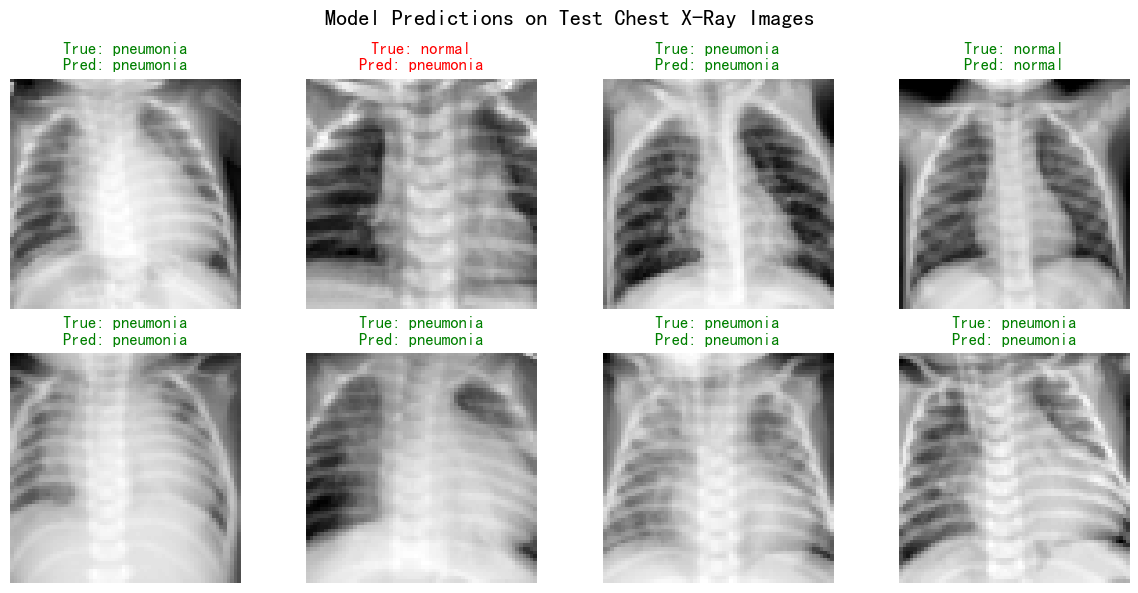

In [15]:
# 获取测试集的一个批次
test_images, test_labels = next(iter(test_loader))

# 进行预测
model.eval()
with torch.no_grad():
    outputs = model(test_images)
    _, predictions_test = outputs.max(1)

# 可视化预测结果
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Model Predictions on Test Chest X-Ray Images', fontsize=16)

for i in range(8):
    ax = axes[i // 4, i % 4]
    
    # 将图像从 [-1, 1] 转换回 [0, 1]
    img = test_images[i].squeeze().numpy() * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    
    ax.imshow(img, cmap='gray')
    
    # 获取真实标签和预测标签
    true_label = info['label'][str(test_labels[i].item())]
    pred_label = info['label'][str(predictions_test[i].item())]
    is_correct = test_labels[i].item() == predictions_test[i].item()
    
    # 设置标题颜色（正确为绿色，错误为红色）
    color = 'green' if is_correct else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

## **从医生的角度理解模型表现**

### **模型准确率的意义**

- 如果模型准确率达到 85-95%，这意味着什么？
  - 相比随机猜测（约 50%），模型已经学到了有用的影像学特征
  - 可以作为放射科医生的辅助工具，但有一定判断错误的概率，不能完全替代医生判断

### **如何理解训练集 vs 验证集的表现**

通过观察训练集和验证集的指标对比，可以判断模型的学习状态：

**1. 欠拟合（Underfitting）**
- 表现：训练集和验证集的准确率都较低
- 原因：模型太简单，无法学习数据的复杂模式
- 解决：增加模型复杂度、训练更长时间

**2. 过拟合（Overfitting）**
- 表现：训练集准确率很高，但验证集准确率明显较低
- 原因：模型"记住"了训练数据，无法泛化到新数据
- 解决：增加数据量、使用正则化（如 Dropout）、早停

**3. 良好拟合（Good Fit）**
- 表现：训练集和验证集准确率相近，都较高
- 说明：模型学到了可泛化的特征

**临床应用中的注意事项：**

1. **假阳性和假阴性**
   - 假阳性：将正常误判为肺炎 - 可能导致不必要的抗生素使用
   - 假阴性：漏掉肺炎患者 - 可能延误治疗，后果更严重

2. **模型局限性**
   - 只能识别训练集中见过的影像模式
   - 对罕见类型的肺炎（如某些特殊病原体感染）识别能力有限
   - 无法获取患者的临床症状（发热、咳嗽、呼吸困难等）


---

# **第六部分：数据不均衡处理对比实验**

## **实验目的**

从之前的实验结果可以看到，模型对肺炎类别（多数类）的识别能力较好，但对正常类别（少数类）的识别能力相对较差：

| 类别 |  说明 |
|------|------|
| normal | 少数类，表现较差 |
| pneumonia | 多数类，表现较好 |

**为什么会出现这种情况？**
- 训练集中肺炎样本（3461个）远多于正常样本（1247个），比例约为 **2.78:1**
- 模型倾向于预测多数类（肺炎），因为这样可以获得更高的整体准确率

**本实验将尝试使用加权损失函数来解决这个问题：**
- 给少数类（正常）更高的权重，让模型更关注少数类
- 对比使用和不使用加权损失函数的模型性能差异

## **加权损失函数的原理说明**

#### **什么是加权损失函数？**

在类别不平衡的数据集中，不同类别的样本数量差异很大。加权损失函数通过给不同类别分配不同的权重，来平衡这种不平衡。

#### **权重计算公式**

```
权重 = 总样本数 / (类别数 × 该类别的样本数)
```

对于 PneumoniaMNIST 数据集：

| 类别 | 样本数 | 权重计算 | 权重 |
|------|--------|----------|------|
| Normal (少数类) | 1247 | 4708 / (2 × 1247) | **1.8877** |
| Pneumonia (多数类) | 3461 | 4708 / (2 × 3461) | **0.6801** |

### **加权损失如何工作？**

1. **对于少数类**：当模型预测少数类错误时，损失会被**放大**
2. **对于多数类**：当模型预测多数类错误时，损失会被**缩小**
3. **效果**：模型会更加关注少数类，因为它会"更害怕"在少数类上犯错

### **什么情况下使用加权损失？**

- **数据存在严重类别不平衡**（如本例中的 2.78:1）
- **少数类的识别特别重要**（如医学诊断中的罕见疾病）
- **希望提高召回率而非准确率**（减少漏诊比减少误诊更重要）

### **定义加权损失函数：**

In [16]:
# 计算类别权重
# 权重公式：weight = total_samples / (num_classes * class_samples)
# 这样少数类会获得更高的权重

total_samples = len(train_dataset)
num_classes = len(info['label'])
class_counts = train_label_counts  # 从之前的数据分布统计中获得

print("=" * 60)
print("计算类别权重:")
print("=" * 60)
print(f"训练集总样本数: {total_samples}")
print(f"类别数: {num_classes}")
print()

class_weights = []
for label_idx in sorted(class_counts.keys()):
    count = class_counts[label_idx]
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)
    label_name = info['label'][str(label_idx)]
    print(f"{label_name} (类别 {label_idx}): {count} 样本 -> 权重 = {weight:.4f}")

print("=" * 60)
print()

# 将权重转换为 PyTorch 张量（注意：权重类型要是 float）
class_weights_tensor = torch.FloatTensor(class_weights)
print(f"类别权重张量: {class_weights_tensor}")
print()

# 定义加权损失函数
# CrossEntropyLoss 的 weight 参数会对每个样本的损失进行加权
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_tensor)

计算类别权重:
训练集总样本数: 4708
类别数: 2

normal (类别 0): 1214 样本 -> 权重 = 1.9390
pneumonia (类别 1): 3494 样本 -> 权重 = 0.6737

类别权重张量: tensor([1.9390, 0.6737])



## **训练加权损失模型**

现在使用加权损失函数训练新模型，并与之前的结果进行对比。

In [17]:
# 创建一个新的模型实例，用于加权损失实验
# 注意：我们需要一个全新的模型，参数随机初始化
model_weighted = SimpleCNN(in_channels=info['n_channels'], num_classes=len(info['label']), image_size=IMAGE_SIZE)

# 为新模型创建一个新的优化器
optimizer_weighted = optim.SGD(model_weighted.parameters(), lr=LEARNING_RATE, momentum=0.9)

print("=" * 60)
print("新模型信息:")
print("=" * 60)
print(f"模型总参数量: {sum(p.numel() for p in model_weighted.parameters()):,}")
print(f"优化器: {optimizer_weighted}")
print("=" * 60)

新模型信息:
模型总参数量: 8,519,650
优化器: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


In [18]:
# 使用加权损失函数训练模型
# 使用之前定义的 train_model 函数，但传入 weighted criterion
# model_name 改为 "加权 CrossEntropyLoss" 以区分

print("开始训练加权损失模型...")
print("=" * 60)

# 调用训练函数，传入加权损失函数
train_results_weighted = train_model(
    model_weighted, train_loader, val_loader, criterion_weighted, optimizer_weighted, NUM_EPOCHS,
    num_classes=len(info['label']),
    model_name="加权 CrossEntropyLoss"  # 区分模型名称
)

# 从返回的字典中提取训练和验证指标
train_losses_weighted = train_results_weighted['train_losses']
train_accs_weighted = train_results_weighted['train_accs']
train_f1s_weighted = train_results_weighted['train_f1s']
val_losses_weighted = train_results_weighted['val_losses']
val_accs_weighted = train_results_weighted['val_accs']
val_f1s_weighted = train_results_weighted['val_f1s']
best_val_f1_weighted = train_results_weighted['best_val_f1']
best_epoch_weighted = train_results_weighted['best_epoch']

开始训练加权损失模型...


[加权 CrossEntropyLoss] Epoch 1/8: 100%|██████████████████████| 74/74 [00:41<00:00,  1.78it/s, loss=0.1571, acc=86.72%]


[加权 CrossEntropyLoss] Epoch 1/8
  Train - Loss: 0.2730, Acc: 86.72%, F1: 84.19%
  Val   - Loss: 0.1251, Acc: 95.04%, F1: 93.72%, Prec: 92.49%, Recall: 95.21%


[加权 CrossEntropyLoss] Epoch 2/8: 100%|██████████████████████| 74/74 [00:39<00:00,  1.85it/s, loss=0.0827, acc=94.77%]


[加权 CrossEntropyLoss] Epoch 2/8
  Train - Loss: 0.1401, Acc: 94.77%, F1: 93.40%
  Val   - Loss: 0.1111, Acc: 95.23%, F1: 94.03%, Prec: 92.45%, Recall: 96.06%


...

[加权 CrossEntropyLoss] Epoch 6/8
  Train - Loss: 0.0775, Acc: 96.94%, F1: 96.08%
  Val   - Loss: 0.0849, Acc: 95.80%, F1: 94.69%, Prec: 93.43%, Recall: 96.20%


[加权 CrossEntropyLoss] Epoch 7/8: 100%|██████████████████████| 74/74 [00:28<00:00,  2.58it/s, loss=0.0311, acc=97.18%]


[加权 CrossEntropyLoss] Epoch 7/8
  Train - Loss: 0.0723, Acc: 97.18%, F1: 96.38%
  Val   - Loss: 0.0900, Acc: 95.99%, F1: 95.00%, Prec: 93.27%, Recall: 97.30%


[加权 CrossEntropyLoss] Epoch 8/8: 100%|██████████████████████| 74/74 [00:33<00:00,  2.22it/s, loss=0.0267, acc=97.73%]


[加权 CrossEntropyLoss] Epoch 8/8
  Train - Loss: 0.0605, Acc: 97.73%, F1: 97.08%
  Val   - Loss: 0.0787, Acc: 96.56%, F1: 95.55%, Prec: 95.13%, Recall: 95.99%
[加权 CrossEntropyLoss] 训练完成！最佳验证集F1分数: 95.55% (Epoch 8)


## **加权损失模型训练结果对比**

绘制加权损失模型的训练和验证指标。

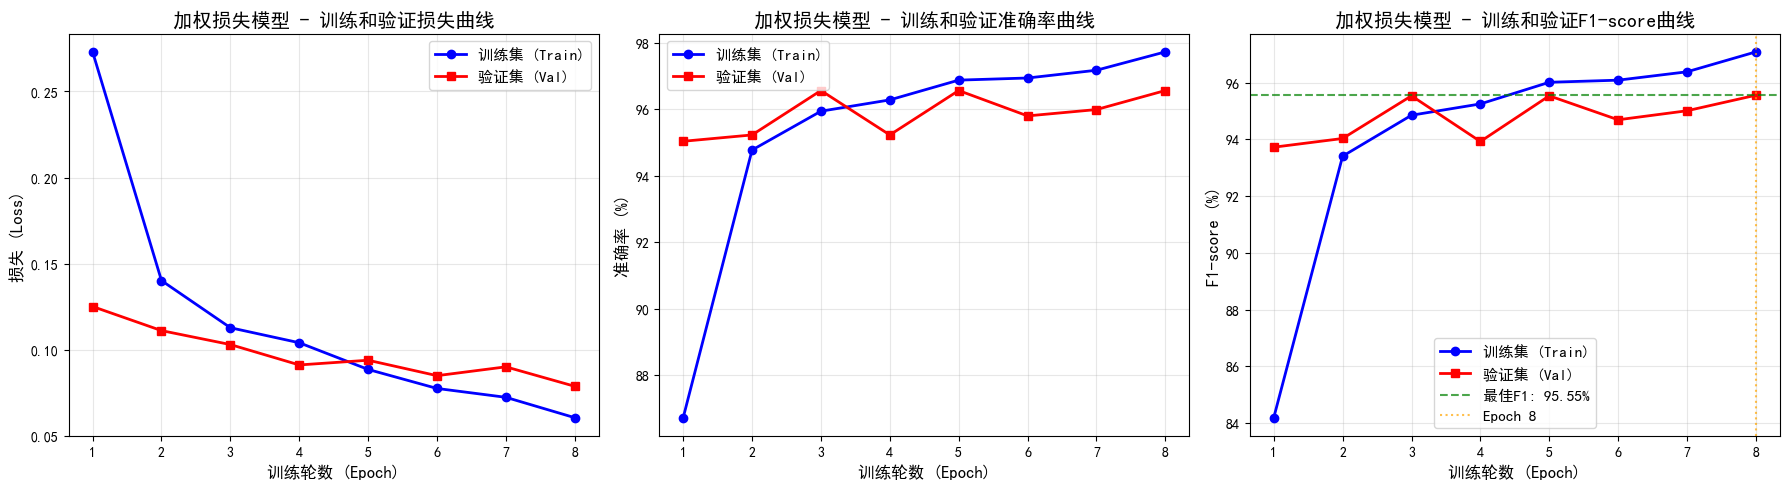

加权损失模型 - 最终训练和验证指标:
训练集 - 损失: 0.0605, 准确率: 97.73%, F1: 97.08%
验证集 - 损失: 0.0787, 准确率: 96.56%, F1: 95.55%
最佳验证集F1分数: 95.55% (Epoch 8)


In [19]:
# 绘制加权损失模型的训练过程（同时显示训练集和验证集）
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 损失曲线
axes[0].plot(range(1, NUM_EPOCHS+1), train_losses_weighted, 'b-o', label='训练集 (Train)', linewidth=2, markersize=6)
axes[0].plot(range(1, NUM_EPOCHS+1), val_losses_weighted, 'r-s', label='验证集 (Val)', linewidth=2, markersize=6)
axes[0].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[0].set_ylabel('损失 (Loss)', fontsize=12)
axes[0].set_title('加权损失模型 - 训练和验证损失曲线', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(range(1, NUM_EPOCHS+1), train_accs_weighted, 'b-o', label='训练集 (Train)', linewidth=2, markersize=6)
axes[1].plot(range(1, NUM_EPOCHS+1), val_accs_weighted, 'r-s', label='验证集 (Val)', linewidth=2, markersize=6)
axes[1].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[1].set_ylabel('准确率 (%)', fontsize=12)
axes[1].set_title('加权损失模型 - 训练和验证准确率曲线', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# F1-score 曲线
axes[2].plot(range(1, NUM_EPOCHS+1), train_f1s_weighted, 'b-o', label='训练集 (Train)', linewidth=2, markersize=6)
axes[2].plot(range(1, NUM_EPOCHS+1), val_f1s_weighted, 'r-s', label='验证集 (Val)', linewidth=2, markersize=6)
axes[2].axhline(y=best_val_f1_weighted, color='g', linestyle='--', alpha=0.7, label=f'最佳F1: {best_val_f1_weighted:.2f}%')
axes[2].axvline(x=best_epoch_weighted, color='orange', linestyle=':', alpha=0.7, label=f'Epoch {best_epoch_weighted}')
axes[2].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[2].set_ylabel('F1-score (%)', fontsize=12)
axes[2].set_title('加权损失模型 - 训练和验证F1-score曲线', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 60)
print("加权损失模型 - 最终训练和验证指标:")
print("=" * 60)
print(f"训练集 - 损失: {train_losses_weighted[-1]:.4f}, 准确率: {train_accs_weighted[-1]:.2f}%, F1: {train_f1s_weighted[-1]:.2f}%")
print(f"验证集 - 损失: {val_losses_weighted[-1]:.4f}, 准确率: {val_accs_weighted[-1]:.2f}%, F1: {val_f1s_weighted[-1]:.2f}%")
print(f"最佳验证集F1分数: {best_val_f1_weighted:.2f}% (Epoch {best_epoch_weighted})")
print("=" * 60)

## **在测试集上评估加权损失模型**

In [20]:
# 在测试集上评估加权损失模型
print("在测试集上评估加权损失模型...")
print("=" * 60)

# 使用 evaluate 函数在测试集上评估
test_metrics_weighted = evaluate(model_weighted, test_loader, criterion_weighted, num_classes=len(info['label']))

print(f"测试集损失: {test_metrics_weighted['loss']:.4f}")
print(f"测试集准确率: {test_metrics_weighted['accuracy']:.2f}%")
print(f"测试集 F1-score (宏平均): {test_metrics_weighted['macro_f1']:.2f}%")
print(f"测试集精确率: {test_metrics_weighted['precision']:.2f}%")
print(f"测试集召回率: {test_metrics_weighted['recall']:.2f}%")
print("=" * 60)

# 打印各类别的 F1-score
print("\n各类别 F1-score:")
for idx, f1 in enumerate(test_metrics_weighted['per_class_f1']):
    print(f"  {info['label'][str(idx)]}: {f1:.2f}%")
print("=" * 60)

在测试集上评估加权损失模型...
测试集损失: 0.8872
测试集准确率: 86.06%
测试集 F1-score (宏平均): 83.84%
测试集精确率: 89.40%
测试集召回率: 81.92%

各类别 F1-score:
  normal: 77.86%
  pneumonia: 89.82%


## **可视化对比：混淆矩阵**

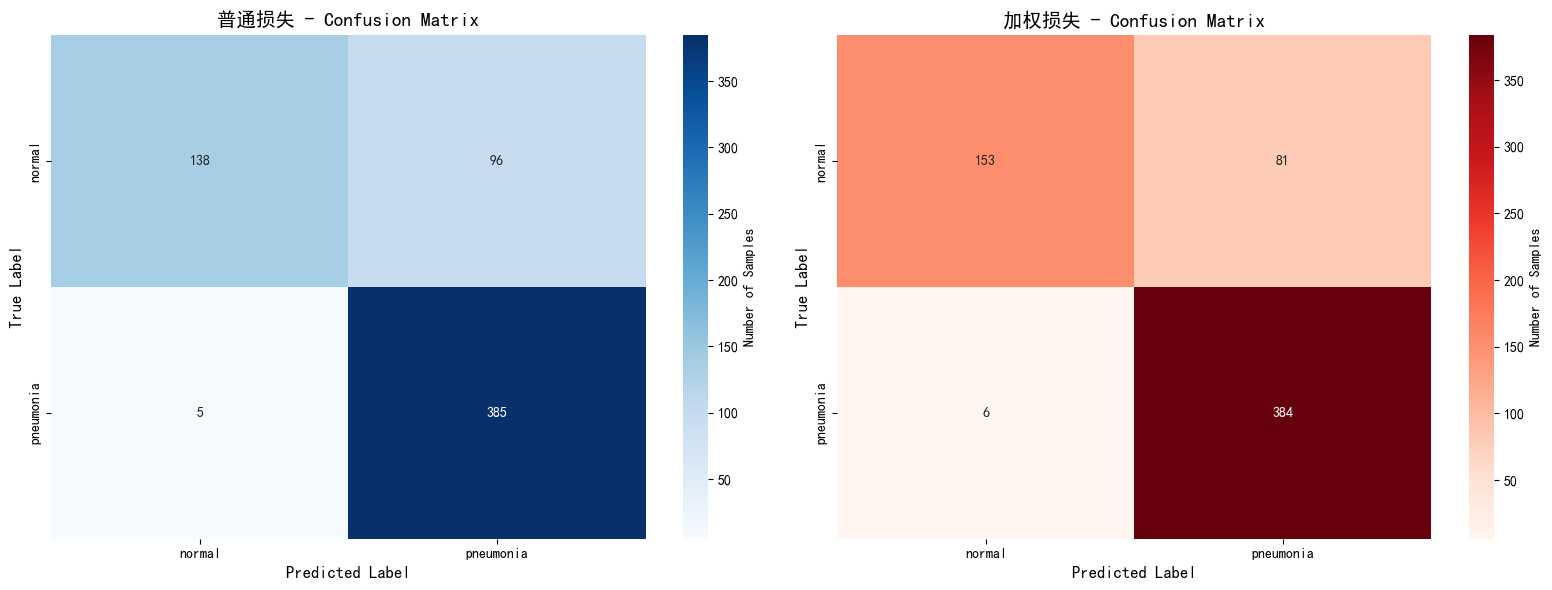

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 计算两个模型的混淆矩阵
cm_normal = test_metrics['confusion_matrix']
cm_weighted = test_metrics_weighted['confusion_matrix']

# 获取类别名称
class_names = [info['label'][str(i)] for i in range(len(info['label']))]

# 绘制对比混淆矩阵
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 普通损失混淆矩阵
sns.heatmap(cm_normal, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'}, ax=axes[0])
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('普通损失 - Confusion Matrix', fontsize=14, fontweight='bold')

# 加权损失混淆矩阵
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'}, ax=axes[1])
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('加权损失 - Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## **可视化对比：训练和验证曲线**

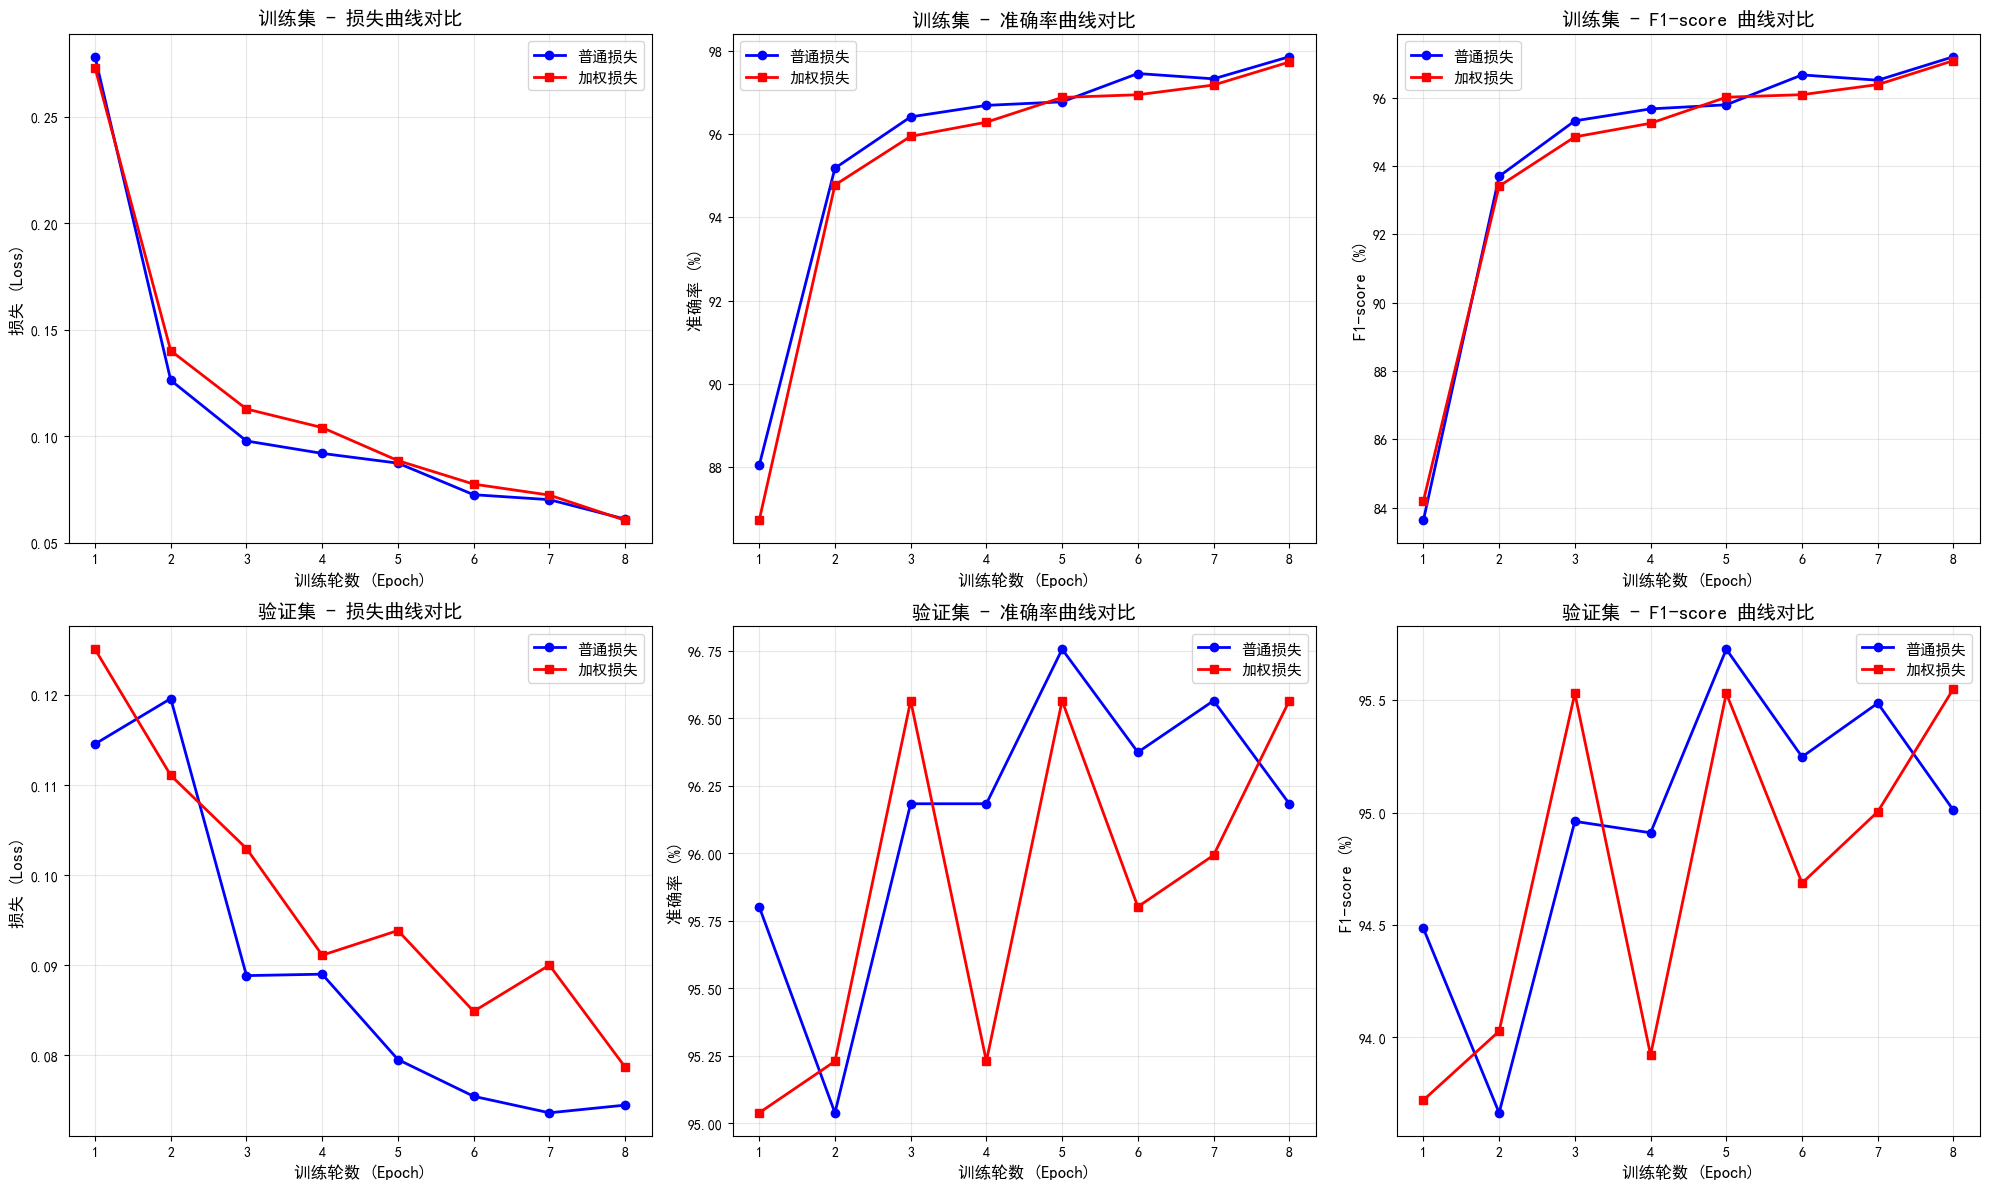

In [22]:
# 可视化对比：普通损失 vs 加权损失
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 训练损失对比
axes[0, 0].plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', label='普通损失', linewidth=2, markersize=6)
axes[0, 0].plot(range(1, NUM_EPOCHS+1), train_losses_weighted, 'r-s', label='加权损失', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[0, 0].set_ylabel('损失 (Loss)', fontsize=12)
axes[0, 0].set_title('训练集 - 损失曲线对比', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 验证损失对比
axes[1, 0].plot(range(1, NUM_EPOCHS+1), val_losses, 'b-o', label='普通损失', linewidth=2, markersize=6)
axes[1, 0].plot(range(1, NUM_EPOCHS+1), val_losses_weighted, 'r-s', label='加权损失', linewidth=2, markersize=6)
axes[1, 0].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[1, 0].set_ylabel('损失 (Loss)', fontsize=12)
axes[1, 0].set_title('验证集 - 损失曲线对比', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 训练准确率对比
axes[0, 1].plot(range(1, NUM_EPOCHS+1), train_accs, 'b-o', label='普通损失', linewidth=2, markersize=6)
axes[0, 1].plot(range(1, NUM_EPOCHS+1), train_accs_weighted, 'r-s', label='加权损失', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[0, 1].set_ylabel('准确率 (%)', fontsize=12)
axes[0, 1].set_title('训练集 - 准确率曲线对比', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 验证准确率对比
axes[1, 1].plot(range(1, NUM_EPOCHS+1), val_accs, 'b-o', label='普通损失', linewidth=2, markersize=6)
axes[1, 1].plot(range(1, NUM_EPOCHS+1), val_accs_weighted, 'r-s', label='加权损失', linewidth=2, markersize=6)
axes[1, 1].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[1, 1].set_ylabel('准确率 (%)', fontsize=12)
axes[1, 1].set_title('验证集 - 准确率曲线对比', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# 训练 F1-score 对比
axes[0, 2].plot(range(1, NUM_EPOCHS+1), train_f1s, 'b-o', label='普通损失', linewidth=2, markersize=6)
axes[0, 2].plot(range(1, NUM_EPOCHS+1), train_f1s_weighted, 'r-s', label='加权损失', linewidth=2, markersize=6)
axes[0, 2].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[0, 2].set_ylabel('F1-score (%)', fontsize=12)
axes[0, 2].set_title('训练集 - F1-score 曲线对比', fontsize=14, fontweight='bold')
axes[0, 2].legend(fontsize=11)
axes[0, 2].grid(True, alpha=0.3)

# 验证 F1-score 对比
axes[1, 2].plot(range(1, NUM_EPOCHS+1), val_f1s, 'b-o', label='普通损失', linewidth=2, markersize=6)
axes[1, 2].plot(range(1, NUM_EPOCHS+1), val_f1s_weighted, 'r-s', label='加权损失', linewidth=2, markersize=6)
axes[1, 2].set_xlabel('训练轮数 (Epoch)', fontsize=12)
axes[1, 2].set_ylabel('F1-score (%)', fontsize=12)
axes[1, 2].set_title('验证集 - F1-score 曲线对比', fontsize=14, fontweight='bold')
axes[1, 2].legend(fontsize=11)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **两种方法的详细对比**

In [23]:
# 详细对比两种方法的性能
print("=" * 80)
print(" " * 28 + "两种方法对比：普通损失 vs 加权损失" + " " * 28)
print("=" * 80)
print()

# 打印总体指标对比
print("| 指标 | 普通损失 | 加权损失 | 差值 |")
print("|------|----------|----------|------|")
print(f"| 测试集准确率 | {test_metrics['accuracy']:.2f}% | {test_metrics_weighted['accuracy']:.2f}% | {test_metrics_weighted['accuracy'] - test_metrics['accuracy']:+.2f}% |")
print(f"| 宏平均 F1-score | {test_metrics['macro_f1']:.2f}% | {test_metrics_weighted['macro_f1']:.2f}% | {test_metrics_weighted['macro_f1'] - test_metrics['macro_f1']:+.2f}% |")
print(f"| 精确率 | {test_metrics['precision']:.2f}% | {test_metrics_weighted['precision']:.2f}% | {test_metrics_weighted['precision'] - test_metrics['precision']:+.2f}% |")
print(f"| 召回率 | {test_metrics['recall']:.2f}% | {test_metrics_weighted['recall']:.2f}% | {test_metrics_weighted['recall'] - test_metrics['recall']:+.2f}% |")
print()

# 打印各类别 F1-score 对比
print("各类别 F1-score 对比:")
print()
print("| 类别 | 普通损失 | 加权损失 | 差值 |")
print("|------|----------|----------|------|")
for idx in range(len(info['label'])):
    class_name = info['label'][str(idx)]
    f1_normal = test_metrics['per_class_f1'][idx]
    f1_weighted = test_metrics_weighted['per_class_f1'][idx]
    diff = f1_weighted - f1_normal
    print(f"| {class_name} | {f1_normal:.2f}% | {f1_weighted:.2f}% | {diff:+.2f}% |")
print()

print("=" * 80)
print("结论分析:")
print("=" * 80)
print(f"1. 宏平均 F1-score: 加权损失 {'提升' if test_metrics_weighted['macro_f1'] > test_metrics['macro_f1'] else '下降'}了 {abs(test_metrics_weighted['macro_f1'] - test_metrics['macro_f1']):.2f}%")
print()

normal_f1_improved = test_metrics_weighted['per_class_f1'][0] > test_metrics['per_class_f1'][0]
pneumonia_f1_improved = test_metrics_weighted['per_class_f1'][1] > test_metrics['per_class_f1'][1]

print(f"2. Normal 类（少数类）F1-score: {'提升' if normal_f1_improved else '下降'}了 {abs(test_metrics_weighted['per_class_f1'][0] - test_metrics['per_class_f1'][0]):.2f}%")
print(f"3. Pneumonia 类（多数类）F1-score: {'提升' if pneumonia_f1_improved else '下降'}了 {abs(test_metrics_weighted['per_class_f1'][1] - test_metrics['per_class_f1'][1]):.2f}%")
print()

if normal_f1_improved:
    print("=> 加权损失函数成功提升了少数类（Normal）的识别能力！")
else:
    print("=> 加权损失函数对少数类的提升效果不明显。")
print()

# 精确率和召回率的变化
precision_change = test_metrics_weighted['precision'] - test_metrics['precision']
recall_change = test_metrics_weighted['recall'] - test_metrics['recall']
print(f"4. 精确率变化: {precision_change:+.2f}% {'(提升)' if precision_change > 0 else '(下降)'}")
print(f"5. 召回率变化: {recall_change:+.2f}% {'(提升)' if recall_change > 0 else '(下降)'}")
print()

if recall_change > precision_change:
    print("=> 加权损失更多提升了召回率（减少漏诊），适合医学诊断场景。")
else:
    print("=> 加权损失更多提升了精确率（减少误诊）。")
print()
print("=" * 80)

                            两种方法对比：普通损失 vs 加权损失                            

| 指标 | 普通损失 | 加权损失 | 差值 |
|------|----------|----------|------|
| 测试集准确率 | 83.81% | 86.06% | +2.24% |
| 宏平均 F1-score | 80.81% | 83.84% | +3.04% |
| 精确率 | 88.27% | 89.40% | +1.13% |
| 召回率 | 78.85% | 81.92% | +3.08% |

各类别 F1-score 对比:

| 类别 | 普通损失 | 加权损失 | 差值 |
|------|----------|----------|------|
| normal | 73.21% | 77.86% | +4.65% |
| pneumonia | 88.40% | 89.82% | +1.42% |

结论分析:
1. 宏平均 F1-score: 加权损失 提升了 3.04%

2. Normal 类（少数类）F1-score: 提升了 4.65%
3. Pneumonia 类（多数类）F1-score: 提升了 1.42%

=> 加权损失函数成功提升了少数类（Normal）的识别能力！

4. 精确率变化: +1.13% (提升)
5. 召回率变化: +3.08% (提升)

=> 加权损失更多提升了召回率（减少漏诊），适合医学诊断场景。



## **总结：数据不均衡处理实验**

本实验对比了两种损失函数对模型性能的影响：

#### **关键要点**

1. **类别不平衡问题**：PneumoniaMNIST 数据集中肺炎样本是正常样本的约 2.78 倍

2. **加权损失策略**：给少数类（正常）更高的权重（约 1.89），给多数类（肺炎）更低的权重（约 0.68）

3. **预期效果**：
   - 提升少数类（正常）的识别能力
   - 可能略微降低多数类的识别能力
   - 提升宏平均 F1-score

#### **其他处理类别不平衡的方法**

除了加权损失函数，还有以下方法：

| 方法 | 说明 |
|------|------|
| **过采样（Oversampling）** | 复制少数类样本，使各类别样本数相近 |
| **欠采样（Undersampling）** | 随机删除多数类样本，使各类别样本数相近 |
| **SMOTE** | 合成少数类样本，生成新的训练样本 |
| **Focal Loss** | 修改损失函数，让模型更容易学习困难样本 |
| **Early Stopping** | 在验证集指标开始下降时停止训练 |

#### **实践建议**

在医学诊断任务中，通常：
- **漏诊**比**误诊**的后果更严重
- 因此应该优先考虑**召回率**而非准确率
- 加权损失函数是提升少数类召回率的有效方法

---

# **第七部分：课后练习**


## **代码练习**

**任务：** 修改模型架构或超参数，观察对性能和过拟合的影响

```python
# 尝试修改以下内容，然后重新训练模型：

# 1. 改变卷积层的数量（增加或减少）
# 2. 改变卷积核的大小（尝试 5x5）
# 3. 改变学习率（尝试 0.01 或 0.0001）
# 4. 添加或移除 Dropout 层，观察过拟合情况

```

**思考：**
- 增加模型复杂度会提高准确率吗？会增加过拟合的风险吗？
- 更大的学习率会让训练更快收敛吗？
- Dropout 的存在对最终性能和过拟合有什么影响？
- 训练集和验证集的指标差距多大算过拟合？

## **思考题**

1. **临床应用思考：** 如果这个模型用于辅助胸片肺炎诊断，你会如何设计临床工作流程？

2. **模型局限性思考：** 你觉得这个模型可能在哪些情况下出错？如何改进？

3. **医学伦理思考：** 使用 AI 辅助诊断时，需要考虑哪些伦理问题？

4. **数据思考：** 如果收集到新的胸片数据，如何让模型持续学习和改进？

5. **多模态思考：** 除了胸片，结合患者的临床指标（如体温、血氧饱和度、白细胞计数）能否进一步提高诊断准确率？如何实现？

6. **过拟合思考：** 观察训练曲线，你认为模型是否存在过拟合？如果有，你会用什么方法来缓解过拟合？

7. **性能改进：** 想要模型效果好，除了模型调参之外还有什么是非常重要的？

---

# **第八部分：课程总结**

## **本节课学到了什么？**

### **1. CNN 的基本概念**
- 卷积层提取局部特征
- 池化层降低维度，保留主要信息
- 全连接层进行最终分类

### **2. CNN 为什么适合影像任务**
- 自动学习特征，无需手工设计
- 参数相对较少，不易过拟合
- 保留图像的空间结构信息

### **3. 使用 PyTorch 构建 CNN**
- 定义模型类（继承 nn.Module）
- 搭建网络结构（卷积、池化、全连接）
- 定义损失函数和优化器
- 训练和评估模型

### **4. 胸片肺炎诊断任务**
- 使用 PneumoniaMNIST 数据集（基于真实儿科胸片）
- 理解医学影像的特点和挑战
- 从医生视角理解模型结果

---

## **与医学的关系**

卷积神经网络在医学影像领域有广泛的应用：

**X光片放射影像诊断：**
- 胸部X光片分类（如肺炎检测、肺结核筛查）
- 骨折检测（X光片自动识别骨折线）
- 乳腺X光片筛查（乳腺癌早期检测）

**CT 影像分析：**
- 肺结节检测与分类
- 脑出血自动识别
- 肿瘤体积测量

**MRI 图像处理：**
- 脑部疾病诊断（脑瘤、阿尔茨海默病）
- 关节软骨损伤评估
- 心脏功能分析

**未来方向：**
- 多模态医学影像融合（X光+CT+MRI）
- 轻量级模型部署到移动设备
- 联邦学习保护患者隐私
- AI 与医生协作的新模式

---

**希望这节课能帮助你理解卷积神经网络的基本原理和在医学影像领域的应用！**